In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Reading the train file

In [2]:
df_train = pd.read_csv('../input/titanic/train.csv',index_col='PassengerId')
df_train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


## Checking for null values in the dataframe

In [3]:
df_train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

## Defining a function for the data preprocessing step

In [4]:
def data_preprocessing(df):
    df = df.drop(['Name','Cabin'],axis=1)
    df['Sex'] = pd.get_dummies(df['Sex'],drop_first=True)
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df.dropna(inplace=True)
    embarked_encoded = pd.get_dummies(df['Embarked'])
    df = pd.concat([df,embarked_encoded],axis=1)
    df = df.drop(['Embarked','S','Ticket'],axis=1)
    return df

## Calling the function on our dataframe

In [5]:
df_train_processed = data_preprocessing(df_train)
df_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    uint8  
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   C         889 non-null    uint8  
 8   Q         889 non-null    uint8  
dtypes: float64(2), int64(4), uint8(3)
memory usage: 51.2 KB


# Visualization

## Importing the libraries

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

## Plotting our target variable

<AxesSubplot:xlabel='Survived', ylabel='count'>

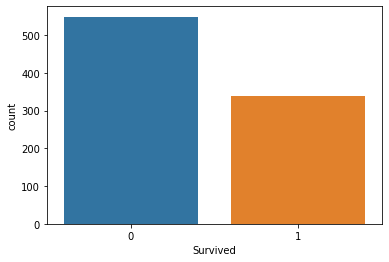

In [7]:
sns.countplot(x=df_train_processed['Survived'])

## Splitting our dataframe into X and y

In [8]:
X = df_train_processed.drop(['Survived'],axis=1)
y = df_train_processed['Survived']

## Balancing our imbalanced dataset with SMOTE

In [9]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority',random_state=17)
X_resampled , y_resampled = smote.fit_resample(X,y)

## Plotting our target variable after Smote sampling

<AxesSubplot:xlabel='Survived', ylabel='count'>

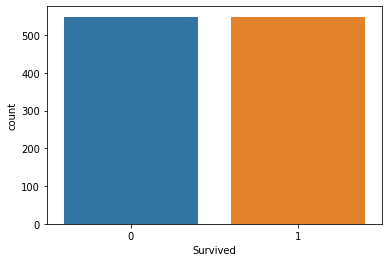

In [10]:
sns.countplot(x=y_resampled)

## Scaling our values in the dataframe using minmax scaler

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_resampled)

In [12]:
X_scaled

array([[1.        , 1.        , 0.27117366, ..., 0.01415106, 0.        ,
        0.        ],
       [0.        , 0.        , 0.4722292 , ..., 0.13913574, 1.        ,
        0.        ],
       [1.        , 0.        , 0.32143755, ..., 0.01546857, 0.        ,
        0.        ],
       ...,
       [0.5       , 0.        , 0.2963056 , ..., 0.03405034, 0.        ,
        0.        ],
       [0.        , 0.        , 0.46933597, ..., 0.43381781, 0.        ,
        0.        ],
       [0.        , 0.        , 0.64758611, ..., 0.15235607, 0.        ,
        0.        ]])

# Splitting our dataset

In [13]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test = train_test_split(X_scaled,y_resampled,test_size=0.2)

# Model Selection

## Importing the models from sklearn

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report,confusion_matrix

In [15]:
models = {'Logistic Regression':LogisticRegression,'Random Forest':RandomForestClassifier,'KNN':KNeighborsClassifier,'Support Vector':SVC,'Naive bayes bernoulli':BernoulliNB}
for i in models:
    clf = models[i]()
    clf.fit(X_train,y_train)
    print(i)
    print(classification_report(y_test,clf.predict(X_test)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       107
           1       0.86      0.81      0.84       113

    accuracy                           0.84       220
   macro avg       0.84      0.84      0.84       220
weighted avg       0.84      0.84      0.84       220

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       107
           1       0.87      0.82      0.85       113

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85      0.85       220

KNN
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       107
           1       0.87      0.83      0.85       113

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85   

## KNN and Random Forest gives us the best results so we will explore them further

### We will use GridSearchCV for hyperparameter tuning

In [16]:
from sklearn.model_selection import GridSearchCV
params = [{'n_neighbors':[1,2,3,4,5],'algorithm':['ball_tree', 'kd_tree', 'brute']}]
knn_clf = KNeighborsClassifier()
final_clf = GridSearchCV(knn_clf,params)
final_clf.fit(X_train,y_train)
print(classification_report(y_test,final_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       107
           1       0.85      0.83      0.84       113

    accuracy                           0.84       220
   macro avg       0.84      0.84      0.84       220
weighted avg       0.84      0.84      0.84       220



In [17]:
params=[{'n_estimators':[10,50,100,150,200,250],'criterion':['gini', 'entropy'],'max_features':['auto','sqrt','log2']}]
rf_clf = RandomForestClassifier()
final_clf = GridSearchCV(rf_clf,params)
final_clf.fit(X_train,y_train)
print(classification_report(y_test,final_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       107
           1       0.88      0.82      0.85       113

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85      0.85       220



## Random forest gives us the highest f1 score so we will finalize it

## Importing the test set

In [18]:
X_test = pd.read_csv('../input/titanic/test.csv',index_col='PassengerId')
submission=pd.DataFrame(X_test.index)
X_test

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [19]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


## Data Preprocessing for test set

In [20]:
X_test = X_test.drop(['Name','Cabin'],axis=1)
X_test['Sex'] = pd.get_dummies(X_test['Sex'],drop_first=True)
X_test['Age'].fillna(X_test['Age'].mean(),inplace=True)
X_test['Fare'].fillna(X_test['Fare'].mean(),inplace=True)
embarked_encoded = pd.get_dummies(X_test['Embarked'])
X_test = pd.concat([X_test,embarked_encoded],axis=1)
X_test_processed = X_test.drop(['Embarked','S','Ticket'],axis=1)

In [21]:
X_test_processed.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 418 entries, 892 to 1309
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  418 non-null    int64  
 1   Sex     418 non-null    uint8  
 2   Age     418 non-null    float64
 3   SibSp   418 non-null    int64  
 4   Parch   418 non-null    int64  
 5   Fare    418 non-null    float64
 6   C       418 non-null    uint8  
 7   Q       418 non-null    uint8  
dtypes: float64(2), int64(3), uint8(3)
memory usage: 20.8 KB


## Scaling the test set

In [22]:
X_test_scaled = scaler.transform(X_test_processed)

In [23]:
X_test_scaled

array([[1.        , 1.        , 0.4282483 , ..., 0.01528158, 0.        ,
        1.        ],
       [1.        , 0.        , 0.58532295, ..., 0.01366309, 0.        ,
        0.        ],
       [0.5       , 1.        , 0.77381252, ..., 0.01890874, 0.        ,
        1.        ],
       ...,
       [1.        , 1.        , 0.47851219, ..., 0.01415106, 0.        ,
        0.        ],
       [1.        , 1.        , 0.3751268 , ..., 0.01571255, 0.        ,
        0.        ],
       [1.        , 1.        , 0.3751268 , ..., 0.0436405 , 1.        ,
        0.        ]])

## Submission is our dataframe with predictions on test set

In [24]:
submission['Survived'] = final_clf.predict(X_test_scaled)

In [25]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [26]:
submission.to_csv('predictions.csv',index=False)

# The End
`If you liked the notebook then don't forget to upvote and suggestions are always welcomed.`
`Follow me on Linkedin :` __[Atharva_Dumbre](https://www.linkedin.com/in/atharva-dumbre-208b5716b)__